---
downloads: []
---

# Modelos estocasticos de Markov


Los **modelos de Markov** son modelos estocásticos utilizados para describir sistemas que evolucionan en el tiempo mediante transiciones aleatorias entre diferentes estados. Su característica fundamental es que la probabilidad del estado futuro depende del estado actual, sin requerir información completa sobre la trayectoria anterior.

En este capítulo introduciremos el concepto de **proceso estocástico**, mediante el cual podemos representar matemáticamente la evolución aleatoria de un sistema a lo largo del tiempo. A partir de esta idea, construiremos las **cadenas de Markov**, una clase particular de procesos estocásticos que satisface la propiedad de Markov.

Estudiaremos la construcción e interpretación de la matriz de transición y la distribución inicial. Posteriormente analizaremos la evolución de las distribuciones de probabilidad, la simulación de trayectorias y su verosimilitud. También estudiaremos el comportamiento de las cadenas a largo plazo.

Finalmente, introduciremos las  cadenas de Markov ocultas, en las cuales los estados del sistema no pueden observarse directamente y deben inferirse a partir de observaciones relacionadas probabilísticamente con ellos.



## 1. Introducción

### 1.1. Que es un procesos estocástico

Una variable aleatoria permite describir el resultado de un experimento aleatorio. En muchas situaciones, sin embargo, no estamos interesados en un único resultado, sino en cómo evoluciona un sistema aleatorio a lo largo del tiempo. Para estudiar este tipo de fenómenos se utilizan los procesos estocásticos.

Un proceso estocástico es una familia de variables aleatorias

$$
\{X_t\}_{t\in T},
$$

donde $T$ es el conjunto de índices que representa el tiempo u otro parámetro. La variable aleatoria $X_t$ describe el estado del sistema en el instante $t$.

Si

$$
T=\{0,1,2,\ldots\},
$$

se tiene un **proceso en tiempo discreto**. Si

$$
T=[0,\infty),
$$

se tiene un **proceso en tiempo continuo**. En este capítulo nos concentraremos en procesos en **tiempo discreto** y, en particular, en aquellos que satisfacen la propiedad de Markov.

### 1.2. Trayectorias de un proceso estocástico

Una **trayectoria** o **realización** de un proceso estocástico corresponde a una secuencia particular de valores que puede tomar el proceso. Para un proceso en tiempo discreto, una trayectoria puede escribirse como

$$
x_0,x_1,x_2,\ldots
$$

y corresponde a una realización concreta

$$
X_0=x_0,\qquad
X_1=x_1,\qquad
X_2=x_2,\ldots
$$

Es importante distinguir entre el proceso estocástico y una trayectoria. El proceso describe el comportamiento probabilístico del sistema, mientras que una trayectoria representa una de las posibles evoluciones que puede observarse.


*#### Ejemplo

Supongamos que $X_t$ representa el estado del clima durante el día $t$, con tres posibles estados:

$$
S=\text{soleado},\qquad
N=\text{nublado},\qquad
L=\text{lluvioso}.
$$

Una posible trayectoria es

$$
S,S,N,L,L,N,S,\ldots
$$

mientras que otra podría ser

$$
L,N,N,S,S,S,N,\ldots
$$

Ambas son realizaciones posibles del mismo proceso. El modelo probabilístico determina las probabilidades asociadas a las diferentes evoluciones del sistema.


## 2. Cadenas de Markov


### 2.1 Definicion y propiedades

Las **cadenas de Markov** son un tipo de proceso estocástico que posee la llamada **propiedad de Markov**. Esta propiedad establece que, conocido el estado presente del sistema, la distribución de probabilidad del estado futuro no depende de los estados anteriores.

En términos informales, se dice que una cadena de Markov **no tiene memoria**: para determinar probabilísticamente qué ocurrirá en el siguiente instante solo es necesario conocer el estado actual. Esta propiedad puede expresarse mediante la siguiente igualdad:

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
=
P(X_{t+1}=x_{t+1}\mid X_t=x_t).
$$

#### **Notación**

La expresión

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
$$

denota la probabilidad condicional de que el proceso pase al estado $x_{t+1}$ en el tiempo $t+1$, dado que se conocen los estados que ha ocupado anteriormente. En particular,

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t)
$$

representa la probabilidad de que el proceso pase al estado $x_{t+1}$ en el tiempo $t+1$, dado que se encuentra en el estado $x_t$ en el tiempo $t$.


#### **Definición**

Una **cadena de Markov** es una colección de variables aleatorias $\{X_t\}_{t\in T}$ que satisface la propiedad de Markov:

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
=
P(X_{t+1}=x_{t+1}\mid X_t=x_t).
$$

Esto significa que el estado futuro $X_{t+1}$ depende probabilísticamente únicamente del estado presente $X_t$ y es independiente de los estados anteriores $X_{t-1},\ldots,X_0$.


#### **Clasificación de las cadenas de Markov**

Las cadenas de Markov pueden clasificarse según la forma en que se considera el tiempo.

- **Cadenas de Markov en tiempo discreto**

  - Los estados del proceso cambian en pasos discretos de tiempo.
  - Se representan mediante una **matriz de transición** $P$.
  - El elemento $P_{ij}$ representa la probabilidad de pasar del estado $i$ al estado $j$ en un solo paso de tiempo.

- **Procesos de Markov en tiempo continuo**

  - El proceso puede cambiar en cualquier instante del tiempo.
  - Se utilizan matrices de tasas de transición, usualmente denotadas por $Q$.
  - El elemento $Q_{ij}$ representa una tasa asociada con la transición del estado $i$ al estado $j$.

En este curso solo trabajaremos con cadenas de Markov de tipo discreto.  A su vez, las cadenas de Markov pueden clasificarse según si sus probabilidades de transición dependen del tiempo:

- **Cadena de Markov homogénea:** las probabilidades de transición son constantes en el tiempo. En este caso,

  $$
  P(X_{t+1}=j\mid X_t=i)=P_{ij}
  $$

  para todo $t$.

- **Cadena de Markov no homogénea:** las probabilidades de transición pueden variar con el tiempo.



### 2.2. El Vector de estado

Para describir la evolución de una cadena de Markov no basta con conocer cuáles son los estados posibles del sistema. También necesitamos conocer cómo se distribuye la probabilidad entre esos estados en cada instante de tiempo. El vector de estado permite representar esta información de manera compacta. Así, en lugar de indicar por separado la probabilidad de encontrarse en cada estado, podemos reunir todas estas probabilidades en un único vector.

Supongamos que un sistema puede encontrarse en $n$ estados posibles,

$$
x_1,x_2,\ldots,x_n.
$$

Si $X_t$ representa el estado del sistema en el tiempo $t$, definimos el **vector de estado** como

$$
\mathbf{v}_t=
(v_{t,1},v_{t,2},\ldots,v_{t,n}),
$$

donde

$$
v_{t,i}=P(X_t=x_i),
\qquad i=1,\ldots,n.
$$

Por tanto,

$$
\mathbf{v}_t=
\big(
P(X_t=x_1),
P(X_t=x_2),
\ldots,
P(X_t=x_n)
\big).
$$

El vector de estado es, entonces, un **vector de probabilidades** que describe la distribución del sistema entre los diferentes estados en el tiempo $t$. Como se trata de una distribución de probabilidad, sus componentes satisfacen

$$
v_{t,i}\geq 0,
\qquad i=1,\ldots,n,
$$

y

$$
\sum_{i=1}^{n}v_{t,i}=1.
$$

Por ejemplo, si un sistema tiene tres estados y

$$
\mathbf{v}_t=(0.2,0.5,0.3),
$$

entonces

$$
P(X_t=x_1)=0.2,\qquad
P(X_t=x_2)=0.5,\qquad
P(X_t=x_3)=0.3.
$$

Así, el vector de estado resume la distribución de probabilidad del sistema en un instante determinado.



### 2.3. La matriz de transición en un proceso de Markov

En una cadena de Markov en tiempo discreto, la **matriz de transición** $P$ permite representar las probabilidades de transición entre los estados del sistema en un intervalo de tiempo. Sea $\{X_t\}_{t\geq 0}$ una cadena de Markov con espacio de estados

$$
S=\{1,2,\ldots,n\}.
$$

La matriz de transición $P$ es una matriz cuadrada de dimensión $n\times n$ cuyos elementos están definidos por

$$
P_{ij}
=
P(X_{t+1}=j\mid X_t=i),
\qquad i,j=1,\ldots,n.
$$

Por tanto,

$$
P=
\begin{pmatrix}
P_{11} & P_{12} & \cdots & P_{1n}\\
P_{21} & P_{22} & \cdots & P_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
P_{n1} & P_{n2} & \cdots & P_{nn}
\end{pmatrix}.
$$

El elemento $P_{ij}$ representa la probabilidad de que el sistema se encuentre en el estado $j$ en el siguiente instante, dado que en el instante actual se encuentra en el estado $i$.

Como cada fila representa una distribución de probabilidad sobre los posibles estados siguientes, se debe cumplir

$$
P_{ij}\geq 0
$$

y

$$
\sum_{j=1}^{n}P_{ij}=1,
\qquad i=1,\ldots,n.
$$

Una matriz que satisface estas condiciones se denomina **matriz estocástica**. Por ejemplo, para una cadena con tres estados, consideremos

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix}.
$$

Si el sistema se encuentra actualmente en el estado $1$, la primera fila indica que las probabilidades de pasar, respectivamente, a los estados $1$, $2$ y $3$ son $0.7$, $0.2$ y $0.1$.

En una **cadena de Markov homogénea**, las probabilidades de transición no dependen del instante $t$. En consecuencia, la misma matriz $P$ describe las transiciones en cada paso de tiempo:

$$
P(X_{t+1}=j\mid X_t=i)=P_{ij}.
$$

La matriz de transición constituye, por tanto, el elemento fundamental para describir la evolución probabilística de la cadena y determinar la distribución de los estados en instantes posteriores.



## 3. Evolución del vector de estado

### 3.1. Multiplicacion vector por matriz

La matriz de transición permite determinar cómo evoluciona el vector de estado de una cadena de Markov. Supongamos que la cadena tiene $n$ estados y que utilizamos vectores de estado como **vectores fila**. Escribimos

$$
\mathbf{v}_t=
\begin{pmatrix}
v_{t,1},\,
v_{t,2},\,
\ldots,\,
v_{t,n}
\end{pmatrix},
$$

donde

$$
v_{t,i}=P(X_t=x_i).
$$

La matriz de transición es

$$
P=
\begin{pmatrix}
p_{11} & p_{12} & \cdots & p_{1n}\\
p_{21} & p_{22} & \cdots & p_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
p_{n1} & p_{n2} & \cdots & p_{nn}
\end{pmatrix},
$$

donde $p_{ij}$ representa la probabilidad de pasar del estado $x_i$ al estado $x_j$ en un paso. El vector de estado en el siguiente instante se obtiene mediante el producto

$$
\boxed{\mathbf{v}_{t+1}=\mathbf{v}_tP}.
$$

Esta multiplicación puede interpretarse como una colección de **productos punto** entre el vector de estado y las columnas de la matriz de transición. En particular,

$$
\mathbf{v}_{t+1}
=
\begin{pmatrix}
v_{t,1},\ldots,v_{t,n}
\end{pmatrix}
P
$$

produce el vector

$$
\mathbf{v}_{t+1}
=
\begin{pmatrix}
\displaystyle\sum_{i=1}^n v_{t,i}p_{i1},
\,
\displaystyle\sum_{i=1}^n v_{t,i}p_{i2},
\,
\ldots,
\,
\displaystyle\sum_{i=1}^n v_{t,i}p_{in}
\end{pmatrix}.
$$

Así, cada componente del nuevo vector se obtiene mediante un producto punto:

$$
v_{t+1,j}
=
\mathbf{v}_t\cdot
\begin{pmatrix}
p_{1j}\\
p_{2j}\\
\vdots\\
p_{nj}
\end{pmatrix}.
$$

Aplicando sucesivamente esta operación,

$$
\mathbf{v}_2=\mathbf{v}_1P
=\mathbf{v}_0P^2,
$$

y, en general,

$$
\boxed{\mathbf{v}_t=\mathbf{v}_0P^t}.
$$

De esta manera, la evolución de una cadena de Markov consiste en aplicar repetidamente la misma transformación al vector de estado.


* #### Ejemplo: evolución del clima

Consideremos un modelo sencillo para el clima de una región. El sistema puede encontrarse en tres estados:

$$
S=\text{soleado},\qquad
N=\text{nublado},\qquad
L=\text{lluvioso}.
$$

Supongamos que el clima del día siguiente depende únicamente del clima del día actual y que la matriz de transición es

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.4 & 0.3\\
0.2 & 0.3 & 0.5
\end{pmatrix}.
$$

Las filas representan el estado actual y las columnas el estado del día siguiente. Supongamos además que el día inicial es soleado. Entonces,

$$
\mathbf{v}_0=(1,0,0).
$$

Utilizando

$$
\mathbf{v}_{t+1}=\mathbf{v}_tP,
$$

obtenemos sucesivamente los vectores de estado. Por ejemplo,

$$
\mathbf{v}_1
=
(1,0,0)
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.4 & 0.3\\
0.2 & 0.3 & 0.5
\end{pmatrix}
=
(0.7,0.2,0.1).
$$

Para el segundo día,

$$
\mathbf{v}_2
=
(0.7,0.2,0.1)P
=
(0.57,0.25,0.18).
$$

A partir de aquí podemos continuar el mismo procedimiento durante un número determinado de días.


### 3.2 Algoritmo para calcular la evolución

El procedimiento puede resumirse en los siguientes pasos:

1. Definir la matriz de transición $P$.
2. Definir el vector de estado inicial $\mathbf{v}_0$.
3. Elegir el número de pasos de tiempo.
4. Calcular $\mathbf{v}_{t+1}=\mathbf{v}_tP$.
5. Guardar cada vector de estado.
6. Repetir los pasos 4 y 5 hasta alcanzar el número de pasos establecido.
7. Representar gráficamente la evolución de cada componente del vector de estado.




### 3.3. Simulacion para evolucionar de los estados  


Cuando se desea estudiar la evolución de una cadena de Markov durante muchos pasos de tiempo, realizar las multiplicaciones sucesivas de forma manual puede resultar dispendioso y poco práctico. Por esta razón, recurriremos a la simulación numérica con Python para automatizar el cálculo de los vectores de estado y estudiar de manera eficiente la evolución del sistema durante un número arbitrario de pasos. Además, la representación gráfica de los resultados facilita identificar patrones y comportamientos que pueden no ser evidentes a partir de unos pocos cálculos.

A continuacion realizamos mostramos una posible implementacion en python de este proceso para el ejemplo del clima considerado en la subseccion 3.1.  


* #### Ejemplo: evolucion del modelo de clima numericamente


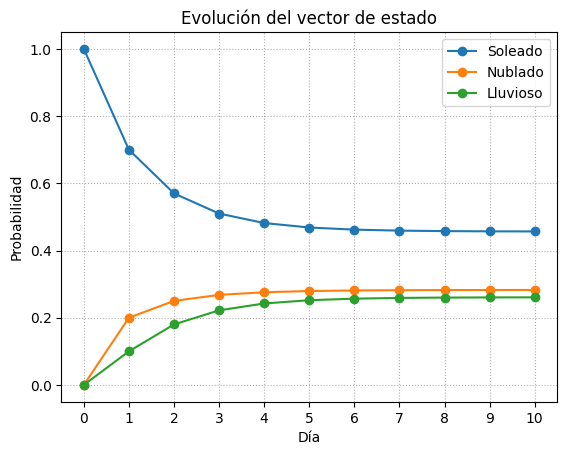

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
])

# Vector de estado inicial
v = np.array([1.0, 0.0, 0.0])

# Número de días
dias = 10

# Guardar los vectores de estado
estados = [v]

for _ in range(dias):
    v = v @ P
    estados.append(v)

estados = np.array(estados)

# Visualización
plt.plot(estados[:, 0], marker="o", label="Soleado")
plt.plot(estados[:, 1], marker="o", label="Nublado")
plt.plot(estados[:, 2], marker="o", label="Lluvioso")

plt.xlabel("Día")
plt.ylabel("Probabilidad")
plt.title("Evolución del vector de estado")
plt.xticks(range(dias + 1))
plt.grid(linestyle=":")
plt.legend()
plt.show()

Note que en el código se uso la expresión

```python
v = v @ P
```

la cual sirve para implementar precisamente la operación del producto vector por matriz:

$$
\mathbf{v}_{t+1}=\mathbf{v}_t   P
$$

Esta es la operacion que consume mas tiempo de nuestra simulación. La gráfica permite observar cómo cambian las probabilidades de los tres estados a medida que transcurre el tiempo.





* #### Ejemplo: dinámica de una población

Consideremos ahora un ecosistema con tres posibles estados para una población de organismos:

- **Abundante (A):** población alta.
- **Moderada (M):** población moderada.
- **Escasa (E):** población baja.

Se han recolectado datos durante varias temporadas para determinar cómo transita la población entre estos estados. La tabla de observaciones es:

| Estado actual $\rightarrow$ estado siguiente | Abundante (A) | Moderada (M) | Escasa (E) |
|---|---:|---:|---:|
| Abundante (A) | 50 | 30 | 20 |
| Moderada (M) | 40 | 50 | 10 |
| Escasa (E) | 30 | 40 | 30 |

A partir de esta información, utilizaremos un modelo de Markov para determinar la distribución de probabilidad de la población después de siete pasos, suponiendo que inicialmente la población es escasa.



##### **Solución**

 1. Cálculo de la matriz de transición:

La probabilidad de transición de un estado $i$ a un estado $j$ se calcula como

$$
P_{ij}
=
\frac{\text{número de transiciones de }i\text{ a }j}
{\text{total de transiciones desde }i}.
$$

Indexemos los estados como:

- Abundante: estado $1$;
- Moderada: estado $2$;
- Escasa: estado $3$.

Para el estado abundante tenemos:

$$
P_{11}
=
\frac{50}{50+30+20}
=0.50,
$$

$$
P_{12}
=
\frac{30}{100}
=0.30,
\qquad
P_{13}
=
\frac{20}{100}
=0.20.
$$

De manera análoga, obtenemos la matriz de transición

$$
P=
\begin{pmatrix}
0.50&0.30&0.20\\
0.40&0.50&0.10\\
0.30&0.40&0.30
\end{pmatrix}.
$$


2. Estado inicial:

Como inicialmente la población es escasa, el vector de estado inicial es

$$
\mathbf{v}_0=(0,0,1).
$$

Después de $7$ pasos,

$$
\mathbf{v}_7=\mathbf{v}_0P^7.
$$



3. Simulacíon

Por tanto, podemos utilizar Python para calcular la evolución de las probabilidades y visualizarla gráficamente.

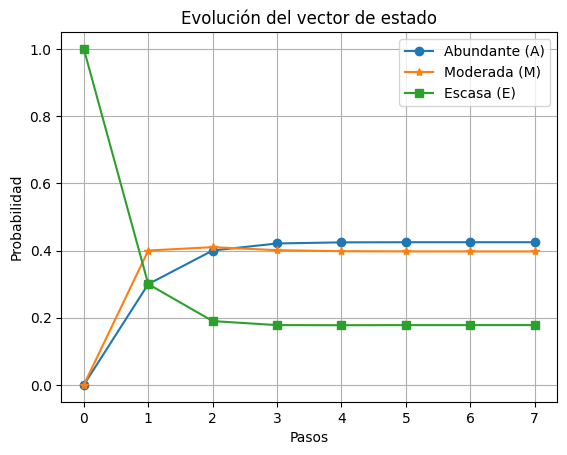

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.50, 0.30, 0.20],
    [0.40, 0.50, 0.10],
    [0.30, 0.40, 0.30]
])

# Distribución inicial:
# comenzamos en el estado Escasa
v = np.array([0, 0, 1])

# Número de pasos
num_steps = 7

# Guardar la evolución
states = [v]

for _ in range(num_steps):
    v = v @ P
    states.append(v)

states = np.array(states)

plt.plot(states[:, 0], 'o-', label="Abundante (A)")
plt.plot(states[:, 1], '*-', label="Moderada (M)")
plt.plot(states[:, 2],'s-', label="Escasa (E)")

plt.title("Evolución del vector de estado")
plt.xlabel("Pasos")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid()
plt.show()





El código permite observar cómo evolucionan las probabilidades asociadas con los tres estados de la población. La distribución obtenida después de siete pasos permite identificar cuál de los tres estados tiene la mayor probabilidad en ese momento.


## 4. Convergencia de cadenas


### 4.1. Cadenas periódicas
Una cadena de Markov es **periódica** cuando el regreso a un estado solo puede ocurrir después de un número de pasos que es múltiplo de un entero mayor que uno. Por ejemplo, consideremos

$$
P=
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix}.
$$

En esta cadena, el sistema alterna necesariamente entre los dos estados:

$$
0\longrightarrow1\longrightarrow0\longrightarrow1\longrightarrow\cdots
$$

Por tanto, ambos estados tienen período $2$. Si partimos del vector

$$
p_0=
\begin{pmatrix}
0.2 & 0.8
\end{pmatrix},
$$

la evolución

$$
p_{t+1}=p_tP
$$

produce

$$
p_{2k}=
\begin{pmatrix}
0.2 & 0.8
\end{pmatrix},
\qquad
p_{2k+1}=
\begin{pmatrix}
0.8 & 0.2
\end{pmatrix}.
$$

En consecuencia, el vector de estado no converge, sino que oscila entre estas dos distribuciones. Es importante observar que esta cadena  sí posee una distribución estacionaria. En efecto,

$$
\pi=
\begin{pmatrix}
1/2 & 1/2
\end{pmatrix}
$$

satisface

$$
\pi P=\pi.
$$

Así, la existencia de una distribución estacionaria no implica necesariamente que $p_t$ converja hacia ella. En una cadena periódica, las probabilidades pueden continuar oscilando indefinidamente.

A continuación presentamos la simulacion de la evolución de los estados


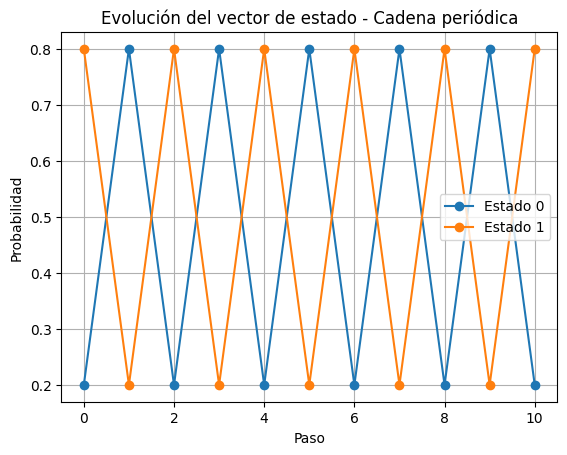

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición periódica
P_periodic = np.array([[0, 1],
                       [1, 0]])

# Vector de estado inicial
p0 = np.array([0.2, 0.8])

# Evolución
n_steps = 10
p = p0
history = [p.copy()]

for _ in range(n_steps):
    p = p @ P_periodic
    history.append(p.copy())

history = np.array(history)

# Graficar evolución
plt.plot(history[:, 0], marker='o', label="Estado 0")
plt.plot(history[:, 1], marker='o', label="Estado 1")

plt.title("Evolución del vector de estado - Cadena periódica")
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(True)
plt.show()

Note que la función `p.copy()` crea una copia independiente del vector de estado `p` en ese instante. Esto es necesario porque `p` cambia en cada iteración del algoritmo. Al utilizar `p.copy()` al guardar cada estado en `history`, conservamos el vector correspondiente a cada paso sin que sea modificado posteriormente. Así, `history` contiene una copia de cada uno de los vectores de estado de la evolución.




### 4.2. Distribución límite

En una cadena de Markov con matriz de transición $P$, una **distribución límite** es un vector de probabilidades hacia el cual converge la distribución del sistema cuando el número de pasos aumenta. Si el límite existe, se define como

$$
\lambda=\lim_{t\to\infty}\mathbf{p}_0P^t.
$$

En determinadas cadenas, este límite es independiente de la distribución inicial $\mathbf{p}_0$. Es decir, aunque el sistema comience con distribuciones diferentes, después de un número suficientemente grande de pasos las probabilidades se aproximan a los mismos valores.

Consideremos la matriz

$$
P=
\begin{pmatrix}
0.6 & 0.3 & 0.1\\
0.2 & 0.5 & 0.3\\
0.1 & 0.2 & 0.7
\end{pmatrix}.
$$

Supongamos que inicialmente el sistema se encuentra con certeza en el estado $1$:

$$
\mathbf{p}_0=
\begin{pmatrix}
1 & 0 & 0
\end{pmatrix}.
$$

Al aplicar sucesivamente la matriz de transición,

$$
\mathbf{p}_t=\mathbf{p}_0P^t,
$$

las probabilidades evolucionan hasta aproximarse a una distribución límite:

$$
\lambda\approx
\begin{pmatrix}
0.286 & 0.357 & 0.357
\end{pmatrix}.
$$

Por ejemplo, después de un número suficientemente grande de pasos,

$$
\mathbf{p}_t\approx\lambda.
$$


El siguiente código permite observar esta convergencia:


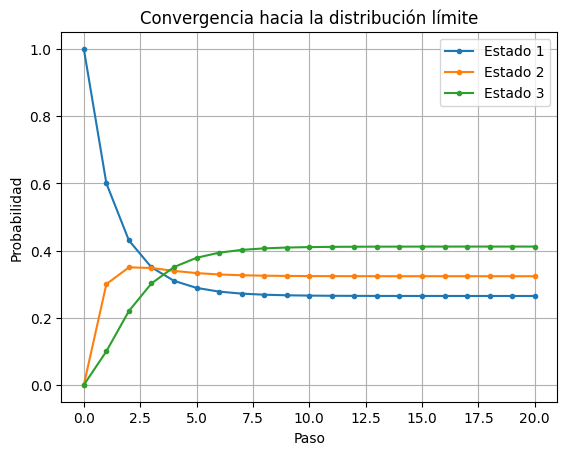

Distribución aproximada después de 20 pasos:
[0.26470829 0.32353041 0.41176131]


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([[0.6, 0.3, 0.1],
              [0.2, 0.5, 0.3],
              [0.1, 0.2, 0.7]])

# Vector de estado inicial
p = np.array([1.0, 0.0, 0.0])

# Número de pasos
n_steps = 20

# Guardar la evolución
history = [p.copy()]

for _ in range(n_steps):
    p = p @ P
    history.append(p.copy())

history = np.array(history)

# Graficar
plt.plot(history[:, 0], marker='o', markersize=3, label="Estado 1")
plt.plot(history[:, 1], marker='o', markersize=3, label="Estado 2")
plt.plot(history[:, 2], marker='o', markersize=3, label="Estado 3")

plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title("Convergencia hacia la distribución límite")
plt.legend()
plt.grid(True)
plt.show()

print("Distribución aproximada después de", n_steps, "pasos:")
print(p)


El gráfico muestra cómo las probabilidades de los tres estados se estabilizan progresivamente. En este caso, la distribución límite coincide con la distribución estacionaria $\lambda$, pero los conceptos no son idénticos: una distribución estacionaria es aquella que permanece inalterada al aplicar $P$, mientras que una distribución límite describe el comportamiento al que converge la cadena cuando $t$ aumenta.



## 6. Trayectorias de cadenas de Markov

### 6.1. ¿Que son las trayectorias?

Una **trayectoria** o **camino** de una cadena de Markov es la secuencia de estados que el sistema visita a lo largo del tiempo. Si $\{X_t\}_{t\geq 0}$ representa la cadena, una trayectoria hasta el instante $t$ puede escribirse como

$$
(X_0,X_1,X_2,\ldots,X_t),
$$

donde $X_k$ representa el estado ocupado por el sistema en el instante $k$. Por ejemplo, una trayectoria de una cadena con tres estados puede ser

$$
(1,2,2,3,1,2,3).
$$

Esta trayectoria representa una **realización particular** de la cadena. En cada paso, el estado siguiente se determina de acuerdo con las probabilidades de transición contenidas en la matriz $P$.

Una forma sencilla de visualizar una trayectoria es representar el tiempo en el eje horizontal y el estado visitado en el eje vertical. Para la trayectoria anterior se obtiene:

```text
Estado
  3 |             ●           ●
  2 |     ●   ●       ●
  1 | ●               ●
    +---------------------------
      0   1   2   3   4   5   6
                  Paso
```


Es importante distinguir entre la **trayectoria** y la **distribución de probabilidad**. La trayectoria muestra una secuencia concreta de estados que puede ocurrir en una realización del proceso, mientras que la distribución describe las probabilidades de encontrar el sistema en cada estado. Por ejemplo, si una cadena tiene tres estados, una distribución en el instante $t$ puede ser

$$
p_t=(0.2,0.5,0.3),
$$

mientras que una trayectoria posible podría ser

$$
(1,2,2,3,1,2,3).
$$

El estudio de diferentes trayectorias permite analizar mediante simulación propiedades de la cadena, como la frecuencia con que se visitan los estados, la periodicidad y el comportamiento a largo plazo.



* #### Ejemplo: Simulación de una trayectoria

Partimos de un estado inicial y, en cada paso, se selecciona aleatoriamente el siguiente estado utilizando las probabilidades de transición de la matriz $P$.

Sea

$$
\mathbf{v}_0=(1,0,0),
$$

el vector de estado inicial. Esto significa que el sistema comienza con certeza en el estado $0$, es decir,

$$
X_0=0.
$$

Consideremos una cadena de Markov con tres estados y matriz de transición

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix}.
$$


A partir del vector de estado inicial $\mathbf{v}_0=(1,0,0)$, simule una trayectoria de $5$ pasos y determine la secuencia de estados visitados. Como el sistema comienza en el estado $0$, la primera selección se realiza utilizando la primera fila de $P$:

$$
P_0=(0.7,0.2,0.1).
$$

Por tanto, desde el estado $0$, el sistema permanece en ese estado con probabilidad $0.7$, pasa al estado $1$ con probabilidad $0.2$ y pasa al estado $2$ con probabilidad $0.1$. Una vez seleccionado el nuevo estado, se utiliza la fila correspondiente de $P$ para determinar el siguiente estado. Este procedimiento se repite hasta completar los $5$ pasos.

En Python:


In [ ]:

import numpy as np

# Matriz de transición
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.1, 0.3, 0.6]
])

# Número de estados
n = 3

# Estado inicial X_0
actual = 0

# Número de pasos
T = 5

# Guardar la trayectoria
trayectoria = [actual]

for t in range(T):

    # Distribución de transición desde el estado actual
    probabilidades = P[actual]

    # Elegir aleatoriamente el siguiente estado
    actual = np.random.choice(n, p=probabilidades)

    trayectoria.append(actual)

print("Trayectoria simulada:")
print(trayectoria)




Una posible ejecución puede producir

```text
Trayectoria simulada:
[0, 0, 1, 1, 2, 1]
```

Esta secuencia representa una posible realización de la cadena:

$$
X_0=0,\quad
X_1=0,\quad
X_2=1,\quad
X_3=1,\quad
X_4=2,\quad
X_5=1.
$$

Por tanto, la trayectoria obtenida es

$$
(X_0,X_1,X_2,X_3,X_4,X_5)
=
(0,0,1,1,2,1).
$$

Es importante notar que esta es solo  una posible trayectori. Al ejecutar nuevamente el programa, puede obtenerse una secuencia diferente, ya que los estados siguientes se seleccionan aleatoriamente de acuerdo con las probabilidades de transición. La simulación permite así generar realizaciones concretas de una cadena de Markov y estudiar experimentalmente su comportamiento.


### 6.2. Verosimilitud de una trayectoria

Una vez definida una trayectoria, podemos preguntarnos  qué tan probable es que la cadena siga exactamente esa secuencia de estados . Esta probabilidad se denomina **verosimilitud de la trayectoria**. Sea una cadena de Markov con matriz de transición $P$ y vector de estado inicial $\mathbf{v}_0$. Una trayectoria es una secuencia de estados

$$
(X_0,X_1,\ldots,X_n).
$$

La probabilidad de observar exactamente esta trayectoria se obtiene multiplicando la probabilidad del estado inicial por las probabilidades de cada una de las transiciones realizadas:

$$
\mathcal{L}(X_0,X_1,\ldots,X_n)
=
v_0(X_0)
\prod_{t=0}^{n-1}P_{X_t,X_{t+1}},
$$

donde $v_0(X_0)$ es la probabilidad inicial de encontrarse en el estado $X_0$, y $P_{X_t,X_{t+1}}$ es la probabilidad de pasar del estado $X_t$ al estado $X_{t+1}$. Si el estado inicial está determinado con certeza, entonces $v_0(X_0)=1$ y la expresión se reduce a

$$
\mathcal{L}(X_0,X_1,\ldots,X_n)
=
\prod_{t=0}^{n-1}P_{X_t,X_{t+1}}.
$$

* #### Ejemplo: Verosimilitud de dos trayectorias

Consideremos la matriz de transición

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix},
$$

donde los estados son $1$, $2$ y $3$. Supongamos que comenzamos en el estado $1$ y observamos la trayectoria

$$
(1,2,2,3,1).
$$

Como el estado inicial es conocido, su probabilidad es $1$. La trayectoria contiene las siguientes transiciones:

$$
1\rightarrow2,\qquad
2\rightarrow2,\qquad
2\rightarrow3,\qquad
3\rightarrow1.
$$

Por lo tanto, su verosimilitud es

$$
\begin{aligned}
\mathcal{L}
&=P_{12}P_{22}P_{23}P_{31}\\
&=(0.2)(0.5)(0.2)(0.1)\\
&=0.002.
\end{aligned}
$$

Así, la probabilidad de que la cadena siga exactamente esta trayectoria es

$$
\boxed{\mathcal{L}=0.002}.
$$

La verosimilitud permite también **comparar diferentes trayectorias**. Dos trayectorias pueden comenzar en el mismo estado, pero tener probabilidades diferentes debido a las transiciones que realizan. Una trayectoria que utiliza transiciones con probabilidades altas tendrá, en general, una verosimilitud mayor que otra que utilice transiciones menos probables. Por ejemplo, podemos comparar dos trayectorias que parten del estado $1$:

$$
T_1=(1,2,2,3,1)
$$

y

$$
T_2=(1,1,2,3,1).
$$

Sus verosimilitudes son

$$
\mathcal{L}(T_1)
=
(0.2)(0.5)(0.2)(0.1)
=
0.002,
$$

y

$$
\mathcal{L}(T_2)
=
(0.7)(0.2)(0.2)(0.1)
=
0.0028.
$$

En este caso, la segunda trayectoria tiene una probabilidad mayor debido a que incluye la transición $1\rightarrow1$, cuya probabilidad es $0.7$.



La verosimilitud es especialmente útil cuando se dispone de  datos observados. Si se observan muchas trayectorias de un sistema, sus probabilidades pueden utilizarse para estudiar qué tan compatibles son con una determinada matriz de transición y, posteriormente, para estimar los parámetros del modelo.


* #### Ejemplo: ¿Cómo encontrar la trayectoria más probable?

Una vez definida la verosimilitud de una trayectoria, podemos preguntarnos cuál es la trayectoria más probable entre todas las trayectorias posibles. Para responder esta pregunta, podemos enumerar las diferentes trayectorias, calcular la verosimilitud de cada una y seleccionar aquella que tenga el mayor valor. En cadenas pequeñas, este procedimiento es sencillo y permite comprender la idea fundamental del problema, como veremos a continuación.
Consideremos tres estados numerados,

$$
S=\{0,1,2\},
$$

con la matriz de transicion dado por

$$
P=
\begin{pmatrix}
0.6&0.3&0.1\\
0.1&0.2&0.7\\
0.1&0.2&0.7
\end{pmatrix},
$$

y con vector de estado inicial

$$
\mathbf{v}_0=(0,1,0).
$$

El sistema comienza en el estado $1$. Supongamos que queremos encontrar la trayectoria más probable durante $T=3$ pasos. Como el estado inicial está determinado, las trayectorias posibles tienen la forma

$$
(1,X_1,X_2,X_3).
$$

Para cada trayectoria calculamos su verosimilitud y las comparamos. En Python podemos utilizar `itertools.product` para generar todas las posibilidades:


Trayectoria más probable:
(1, 2, 2, 2)
Verosimilitud:
0.3429999999999999


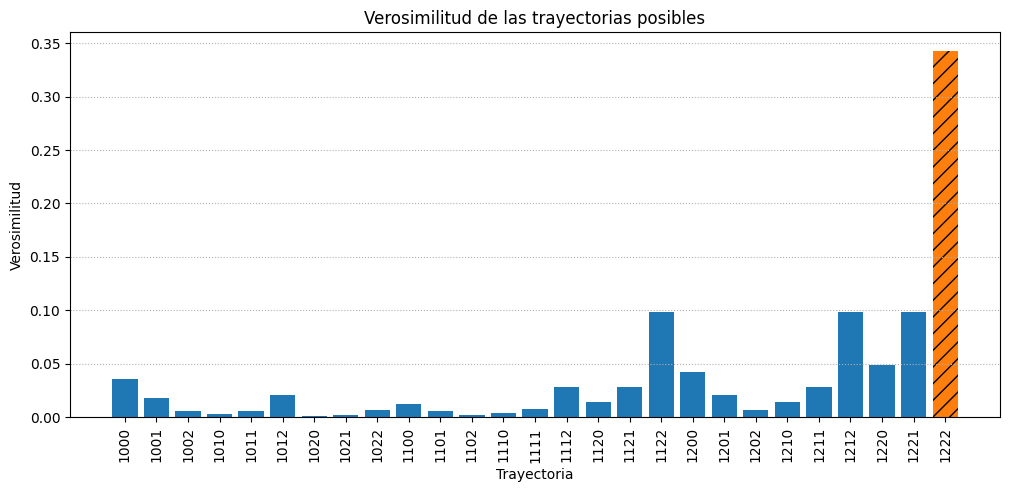

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.6, 0.3, 0.1],
    [0.1, 0.2, 0.7],
    [0.1, 0.2, 0.7]
])

# Vector de estado inicial
v0 = np.array([0, 1, 0])

# Guardar trayectorias y verosimilitudes
trayectorias = []
verosimilitudes = []

# Mejor trayectoria encontrada
mejor_trayectoria = None
mejor_verosimilitud = 0

# Generar todas las trayectorias posibles
for x1 in range(3):
    for x2 in range(3):
        for x3 in range(3):

            trayectoria = (1, x1, x2, x3)

            # Calcular la verosimilitud
            verosimilitud = (
                P[1, x1] *
                P[x1, x2] *
                P[x2, x3]
            )

            # Guardar los resultados
            trayectorias.append(trayectoria)
            verosimilitudes.append(verosimilitud)

            # Comparar con la mejor trayectoria encontrada
            if verosimilitud > mejor_verosimilitud:
                mejor_verosimilitud = verosimilitud
                mejor_trayectoria = trayectoria

# Mostrar la trayectoria más probable
print("Trayectoria más probable:")
print(mejor_trayectoria)

print("Verosimilitud:")
print(mejor_verosimilitud)

# Crear etiquetas para las trayectorias
etiquetas = []

for trayectoria in trayectorias:
    etiqueta = ""
    for estado in trayectoria:
        etiqueta = etiqueta + str(estado)
    etiquetas.append(etiqueta)

# Encontrar la posición de la mejor trayectoria
posicion_mejor = verosimilitudes.index(mejor_verosimilitud)

# Gráfico de las verosimilitudes
plt.bar(etiquetas, verosimilitudes)

# Resaltar la trayectoria más probable
plt.bar(
    posicion_mejor,
    mejor_verosimilitud,
    hatch="//"
)

plt.xlabel("Trayectoria")
plt.ylabel("Verosimilitud")
plt.title("Verosimilitud de las trayectorias posibles")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle=":")

plt.show()


Noet que enel codigo anterior el método `arreglo.index()` permite buscar un elemento dentro de una lista y devuelve la posición en la que se encuentra. Si el elemento no está presente, genera un error. Por tanto, en el código, la instrucción

```python
posicion_mejor = verosimilitudes.index(mejor_verosimilitud)
```

permite obtener el índice de la mejor verosimilitud. Este índice corresponde también a la posición de la trayectoria asociada en la lista `trayectorias`.



## 7. Cadenas de Markov ocultas (opcional)

### 7.1. Elementos básicos

En una cadena de Markov ordinaria, el estado del sistema puede observarse directamente. Sin embargo, en muchos problemas de modelamiento el estado que determina la evolución del sistema **no es observable directamente**. En su lugar, podemos observar ciertas variables o eventos que dependen probabilísticamente de dicho estado.

Una **cadena de Markov oculta** (*Hidden Markov Model*, HMM) es un modelo en el que existe una secuencia de estados que evoluciona de acuerdo con una cadena de Markov, pero estos estados permanecen ocultos. En cada instante de tiempo se obtiene una **observación** que depende probabilísticamente del estado oculto correspondiente.

Denotemos por $X_t$ el estado oculto del sistema y por $Y_t$ la observación en el instante $t$. La estructura del modelo puede representarse como

$$
X_0\longrightarrow X_1\longrightarrow X_2\longrightarrow\cdots
$$

con las observaciones asociadas

$$
Y_0,\qquad Y_1,\qquad Y_2,\qquad\ldots
$$

donde cada $Y_t$ depende del estado oculto $X_t$. El modelo establece, por tanto, dos relaciones probabilísticas fundamentales:

1. **Transición entre estados ocultos.** El estado siguiente depende únicamente del estado actual:

$$
P(X_{t+1}=x_j\mid X_t=x_i)=p_{ij}.
$$

Estas probabilidades se organizan en la **matriz de transición**

$$
P=
\begin{pmatrix}
p_{11}&p_{12}&\cdots&p_{1n}\\
p_{21}&p_{22}&\cdots&p_{2n}\\
\vdots&\vdots&\ddots&\vdots\\
p_{n1}&p_{n2}&\cdots&p_{nn}
\end{pmatrix}.
$$

Cada fila de $P$ suma $1$.

2. **Emisión de observaciones.** La observación depende probabilísticamente del estado oculto:

$$
P(Y_t=y_j\mid X_t=x_i)=b_{ij}.
$$

Estas probabilidades se organizan en la **matriz de emisión**

$$
B=
\begin{pmatrix}
b_{11}&b_{12}&\cdots&b_{1m}\\
b_{21}&b_{22}&\cdots&b_{2m}\\
\vdots&\vdots&\ddots&\vdots\\
b_{n1}&b_{n2}&\cdots&b_{nm}
\end{pmatrix},
$$

donde $n$ es el número de estados ocultos y $m$ el número de posibles observaciones. Cada fila de $B$ suma $1$.

Finalmente, se especifica un vector de probabilidades iniciales

$$
\mathbf{v}_0=
\begin{pmatrix}
P(X_0=x_1)&\cdots&P(X_0=x_n)
\end{pmatrix}.
$$

De esta manera, un HMM queda determinado por

$$
\boxed{(\mathbf{v}_0,P,B)}.
$$

### 7.2. De los estados ocultos a las observaciones

La matriz de transición y la matriz de emisión cumplen funciones diferentes. La primera describe la **evolución de los estados ocultos**, mientras que la segunda establece cómo esos estados se manifiestan en las observaciones. Por ejemplo, si en un instante la distribución de probabilidad de los estados ocultos es

$$
\mathbf{v}_t,
$$

la distribución en el instante siguiente se obtiene mediante

$$
\mathbf{v}_{t+1}=\mathbf{v}_tP.
$$

Una vez conocido el estado oculto, la matriz $B$ permite determinar la distribución de las observaciones. Si $B$ contiene las probabilidades de emisión, entonces la probabilidad de una observación particular se obtiene seleccionando la columna correspondiente de $B$. Así, la evolución completa del modelo puede esquematizarse como

$$
\mathbf{v}_0
\xrightarrow{\;P\;}
\mathbf{v}_1
\xrightarrow{\;P\;}
\mathbf{v}_2
\xrightarrow{\;P\;}
\cdots
$$

mientras que, en cada instante, $B$ relaciona la distribución de los estados con la distribución de las observaciones.



* #### Ejemplo

Supongamos que un sistema tiene dos estados ocultos, $A$ e $I$, y dos posibles observaciones, $H$ y $L$. Consideremos las matrices

$$
P=
\begin{pmatrix}
0.8 & 0.2\\
0.3 & 0.7
\end{pmatrix},
\qquad
B=
\begin{pmatrix}
0.9 & 0.1\\
0.2 & 0.8
\end{pmatrix}.
$$

Supongamos que inicialmente la distribución de probabilidad de los estados ocultos es

$$
\mathbf{v}_0=
\begin{pmatrix}
0.5 & 0.5
\end{pmatrix}.
$$

Después de una transición, la distribución de los estados es

$$
\mathbf{v}_1=\mathbf{v}_0P.
$$

Por tanto,

$$
\mathbf{v}_1=
\begin{pmatrix}
0.5 & 0.5
\end{pmatrix}
\begin{pmatrix}
0.8 & 0.2\\
0.3 & 0.7
\end{pmatrix}
=
\begin{pmatrix}
0.55 & 0.45
\end{pmatrix}.
$$

Esto significa que, en el siguiente instante, la probabilidad de encontrarnos en el estado $A$ es $0.55$, mientras que la probabilidad de encontrarnos en $I$ es $0.45$. Ahora podemos utilizar la matriz de emisión para determinar la distribución de las observaciones. Como las columnas de $B$ corresponden a $H$ y $L$, tenemos

$$
\mathbf{w}_1=\mathbf{v}_1B.
$$

Entonces,

$$
\mathbf{w}_1=
\begin{pmatrix}
0.55 & 0.45
\end{pmatrix}
\begin{pmatrix}
0.9 & 0.1\\
0.2 & 0.8
\end{pmatrix}
=
\begin{pmatrix}
0.585 & 0.415
\end{pmatrix}.
$$

Por tanto,

$$
P(Y_1=H)=0.585
$$

y

$$
P(Y_1=L)=0.415.
$$

Este cálculo muestra las dos etapas del modelo. Primero, la matriz $P$ determina cómo evoluciona la distribución de los **estados ocultos**:

$$
\mathbf{v}_0
\xrightarrow{\;P\;}
\mathbf{v}_1.
$$

Después, la matriz $B$ transforma esta distribución en una distribución sobre las **observaciones**:

$$
\mathbf{v}_1
\xrightarrow{\;B\;}
\mathbf{w}_1.
$$

En consecuencia, para este modelo podemos representar el proceso como

$$
\boxed{
\mathbf{v}_0
\xrightarrow{\;P\;}
\mathbf{v}_1
\xrightarrow{\;B\;}
\mathbf{w}_1
}
$$

donde $\mathbf{v}_t$ describe la distribución de los estados ocultos y $\mathbf{w}_t$ la distribución de las observaciones.



### 7.3. De las observaciones a los estados ocultos

El problema central de un modelo oculto aparece cuando conocemos las observaciones

$$
Y_0,Y_1,\ldots,Y_T
$$

pero desconocemos los estados

$$
X_0,X_1,\ldots,X_T.
$$

En este caso queremos determinar qué estados ocultos son compatibles con las observaciones y cuáles son más probables. La matriz de emisión es fundamental para esta tarea, pues permite evaluar qué tan probable es una observación bajo cada estado oculto. Por ejemplo, si una determinada observación $y$ tiene

$$
P(Y_t=y\mid X_t=x_1)=0.8
$$

y

$$
P(Y_t=y\mid X_t=x_2)=0.2,
$$

la observación proporciona evidencia a favor del estado $x_1$. Sin embargo, no basta con analizar cada observación de manera independiente. También debemos considerar cómo los estados pueden sucederse unos a otros. Esta información está contenida en la matriz de transición $P$. Por esta razón, para inferir los estados ocultos se combinan las probabilidades de **emisión** y **transición**. Para una trayectoria

$$
x_0,x_1,\ldots,x_T
$$

y una secuencia de observaciones

$$
y_0,y_1,\ldots,y_T,
$$

su probabilidad conjunta puede escribirse como

$$
\boxed{
P(X_1=x_1,\ldots,X_{10}=x_{10},
Y_1=y_1,\ldots,Y_{10}=y_{10})
=
P(X_1=x_1)
\prod_{t=1}^{9}p_{x_t x_{t+1}}
\prod_{t=1}^{10}b_{x_t y_t}
}
$$

Donde P(X_1=x_1) es simplemente la probabilidad inicial de que el primer estado oculto sea $x_1$. Esta expresión muestra claramente el papel de las dos matrices:

* $P$ determina la probabilidad de **seguir una determinada trayectoria de estados**.
* $B$ determina la probabilidad de **obtener las observaciones asociadas a esa trayectoria**.

El problema consiste entonces en encontrar, a partir de las observaciones, las trayectorias ocultas que tienen mayor probabilidad. Para cadenas pequeñas es posible enumerar las trayectorias y comparar sus probabilidades. Sin embargo, el número de trayectorias crece rápidamente con la longitud de la secuencia.  De esta manera, el análisis de una cadena de Markov oculta puede entenderse como un problema de dos direcciones:

$$
\boxed{
\text{Estados ocultos}
\overset{B}{\longrightarrow}
\text{Observaciones}
}
$$

para describir cómo se generan los datos, y

$$
\boxed{
\text{Observaciones}
\longrightarrow
\text{Estados ocultos}
}
$$



* ####  Ejemplo: inferir el clima a partir del uso de un paraguas

Supongamos que queremos conocer el estado del clima durante varios días, pero no tenemos acceso directamente a las condiciones meteorológicas. Sin embargo, todos los días observamos si una persona lleva o no un paraguas. El estado del clima será la variable oculta, mientras que el uso del paraguas será la variable observable. Consideremos dos posibles estados:

- $L$: está lloviendo.
- $S$: está soleado, es decir, no está lloviendo.

Y dos posibles observaciones:

- $P$: la persona lleva paraguas.
- $N$: la persona no lleva paraguas.

El estado del clima no puede observarse directamente en nuestro modelo, pero podemos observar si la persona lleva paraguas.

##### **Probabilidades de transición**

Supongamos que el clima de un día depende del clima del día anterior. Consideremos la siguiente matriz de transición:

$$
P=
\begin{pmatrix}
0.8 & 0.2\\
0.3 & 0.7
\end{pmatrix}.
$$

Las filas corresponden al estado del día actual y las columnas al estado del día siguiente. Por ejemplo,

$$
P(X_{t+1}=L\mid X_t=L)=0.8
$$

indica que, si hoy está lloviendo, la probabilidad de que mañana también llueva es $0.8$. Por otro lado,

$$
P(X_{t+1}=S\mid X_t=S)=0.7.
$$

Por tanto, el modelo supone que las condiciones meteorológicas tienden a mantenerse de un día al siguiente.

##### **Probabilidades de observación**

Supongamos ahora que la probabilidad de llevar un paraguas depende del clima. Consideremos la matriz de emisión

$$
B=
\begin{pmatrix}
0.9 & 0.1\\
0.2 & 0.8
\end{pmatrix},
$$

donde las columnas corresponden a las observaciones $P$ y $N$, respectivamente.

Así,

$$
P(Y_t=P\mid X_t=L)=0.9,
$$

mientras que

$$
P(Y_t=P\mid X_t=S)=0.2.
$$

Es decir, cuando está lloviendo es mucho más probable que la persona lleve un paraguas. Sin embargo, también puede llevarlo aunque no esté lloviendo.Finalmente, supongamos que las probabilidades iniciales son

$$
\mathbf{v}_0=
\begin{pmatrix}
0.5 & 0.5
\end{pmatrix}.
$$

##### **Problema**

Supongamos que durante diez días observamos si una persona lleva o no un paraguas. Los resultados son:

| Día | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Paraguas | $P$ | $P$ | $N$ | $P$ | $P$ | $P$ | $N$ | $N$ | $N$ | $P$ |

Conocemos las observaciones, pero no conocemos el estado del clima de cada día. Queremos determinar cuál es la secuencia de estados climáticos más probable:

$$
X_1,X_2,\ldots,X_{10}.
$$

Por ejemplo, una posible secuencia sería

$$
(L,L,L,L,L,L,L,L,L,L),
$$

mientras que otra podría ser

$$
(L,L,S,L,L,L,S,S,S,L).
$$

Cada una de estas secuencias representa una posible explicación de las observaciones. Como existen dos estados posibles para cada uno de los diez días, tenemos

$$
2^{10}=1024
$$

secuencias posibles. En este ejemplo podemos utilizar una **búsqueda exhaustiva**: generaremos todas las secuencias posibles, calcularemos su probabilidad y seleccionaremos aquella que tenga mayor probabilidad.


##### **Probabilidad de una trayectoria**

Para una determinada secuencia de estados

$$
x_1,x_2,\ldots,x_{10}
$$

y la secuencia observada

$$
y_1,y_2,\ldots,y_{10},
$$

la probabilidad conjunta está dada por

$$
P(X_1=x_1,\ldots,X_{10}=x_{10},
Y_1=y_1,\ldots,Y_{10}=y_{10})
$$

$$
=
P(X_1=x_1)
\prod_{t=1}^{9}p_{x_t x_{t+1}}
\prod_{t=1}^{10}b_{x_t y_t}.
$$

Consideremos, por ejemplo, la trayectoria

$$
(L,L,S,L,L,L,S,S,S,L).
$$

Para esta trayectoria debemos multiplicar:

- la probabilidad inicial de comenzar en $L$;
- las probabilidades de las nueve transiciones entre días consecutivos;
- las probabilidades de observar cada uno de los diez resultados de paraguas.


Por ejemplo, para el primer día tenemos

$$
P(X_1=L)P(Y_1=P\mid X_1=L)
=
0.5(0.9).
$$

Para la transición del día 1 al día 2 tenemos

$$
P(X_2=L\mid X_1=L)=0.8.
$$

Y para la transición del día 2 al día 3 tenemos

$$
P(X_3=S\mid X_2=L)=0.2.
$$

El mismo procedimiento se repite para todos los días. La probabilidad completa de la trayectoria se obtiene multiplicando todos estos factores.


##### **Búsqueda de la trayectoria más probable por busqueda exhaustiva**

El procedimiento que utilizaremos es:

1. Generar las $1024$ secuencias posibles de estados.
2. Calcular la probabilidad de cada secuencia.
3. Comparar las probabilidades.
4. Seleccionar la secuencia con mayor probabilidad.

De esta manera podemos inferir el estado del clima sin observarlo directamente.



In [3]:

import itertools

# Estados ocultos
estados = ["L", "S"]

# Observaciones
observaciones = ["P", "P", "N", "P", "P",
                 "P", "N", "N", "N", "P"]

# Probabilidades iniciales
v0 = {
    "L": 0.5,
    "S": 0.5
}

# Matriz de transición
P = {
    "L": {"L": 0.8, "S": 0.2},
    "S": {"L": 0.3, "S": 0.7}
}

# Matriz de emisión
B = {
    "L": {"P": 0.9, "N": 0.1},
    "S": {"P": 0.2, "N": 0.8}
}

# Generar todas las trayectorias posibles
trayectorias = itertools.product(
    estados,
    repeat=len(observaciones)
)

mejor_trayectoria = None
mejor_probabilidad = 0

# Evaluar cada trayectoria
for trayectoria in trayectorias:

    # Probabilidad inicial y primera observación
    probabilidad = (
        v0[trayectoria[0]]
        * B[trayectoria[0]][observaciones[0]]
    )

    # Transiciones y emisiones restantes
    for t in range(1, len(observaciones)):

        estado_anterior = trayectoria[t - 1]
        estado_actual = trayectoria[t]

        probabilidad *= P[estado_anterior][estado_actual]
        probabilidad *= B[estado_actual][observaciones[t]]

    # Guardar la trayectoria más probable
    if probabilidad > mejor_probabilidad:
        mejor_probabilidad = probabilidad
        mejor_trayectoria = trayectoria

print("Observaciones:")
print(observaciones)

print("\nTrayectoria más probable:")
print(mejor_trayectoria)

print("\nProbabilidad:")
print(mejor_probabilidad)


Observaciones:
['P', 'P', 'N', 'P', 'P', 'P', 'N', 'N', 'N', 'P']

Trayectoria más probable:
('L', 'L', 'L', 'L', 'L', 'L', 'S', 'S', 'S', 'L')

Probabilidad:
0.0001310666765893633



La gráfica permite comparar las dos secuencias: la observable, que indica si la persona lleva paraguas, y la secuencia de estados del clima inferida por el modelo. Las dos secuencias no tienen por qué coincidir, ya que una persona puede llevar paraguas aunque no llueva, o no llevarlo aunque esté lloviendo. Por ello, una observación aislada no determina con certeza el estado del clima.

La inferencia combina las **probabilidades de emisión** con las **probabilidades de transición**. Así, las observaciones proporcionan información sobre el estado oculto, mientras que la matriz $P$ incorpora la dependencia entre días consecutivos. La idea fundamental puede resumirse como

$$
\boxed{
\text{Clima oculto}
\longrightarrow
\text{Uso observable del paraguas}
}
$$

y el objetivo de la inferencia es recorrer el proceso en sentido contrario:

$$
\boxed{
\text{Observaciones}
\longrightarrow
\text{Clima más probable}
}
$$

En este ejemplo es posible evaluar todas las trayectorias porque la secuencia es corta. Sin embargo, con $T$ observaciones y dos estados existen $2^T$ trayectorias posibles. Por ejemplo,

$$
2^{20}=1\,048\,576.
$$

Por esta razón, para secuencias largas se requieren métodos más eficientes que la búsqueda exhaustiva. **El algoritmo de Viterbi** permite resolver este problema de manera eficiente, identificando la secuencia de estados ocultos más probable sin necesidad de evaluar todas las trayectorias posibles. En la siguiente sección introduciremos este algoritmo y veremos cómo aplicarlo a este tipo de modelos.




### 7.4. Algoritmo de Viterbi

El algoritmo de Viterbi utiliza **programación dinámica** para encontrar la trayectoria de estados ocultos más probable sin necesidad de enumerar todas las trayectorias posibles. La idea es sencilla: en cada instante, para cada estado posible, se consideran las diferentes trayectorias que pueden llegar hasta él y se conserva únicamente la de mayor probabilidad.

Para formalizar este procedimiento, definimos $\delta_t(j)$ como la mayor probabilidad conjunta de una trayectoria que termina en el estado $j$ en el instante $t$ y que es compatible con las observaciones realizadas hasta ese momento.

El algoritmo puede resumirse en los siguientes pasos.

1. **Inicialización**

   En el primer instante no existen estados anteriores que considerar. Por tanto, para cada estado $j$ se multiplica la probabilidad de comenzar en ese estado por la probabilidad de producir la primera observación:

   $$
   \delta_0(j)=v_0(j)B_{j,Y_0}.
   $$

   Así obtenemos la probabilidad de cada posible estado inicial teniendo en cuenta la primera observación.

2. **Buscar la mejor trayectoria**

   Para avanzar al instante $t$, supongamos que queremos llegar al estado $j$. Podemos haber llegado desde cualquiera de los estados $i$ del instante anterior. Para cada posibilidad calculamos

   $$
   \delta_{t-1}(i)P_{ij}.
   $$

   Esta expresión combina la mejor trayectoria que llegaba al estado $i$ con la probabilidad de pasar de $i$ a $j$. Nos quedamos con la mayor de estas probabilidades y consideramos además la probabilidad de producir la observación $Y_t$:

   $$
   \delta_t(j)
   =
   B_{j,Y_t}
   \max_i
   \left[
   \delta_{t-1}(i)P_{ij}
   \right].
   $$

3. **Guardar de dónde viene la mejor trayectoria**

   No basta con conocer la probabilidad máxima; también necesitamos saber qué estado anterior produjo ese máximo. Para ello guardamos

   $$
   \psi_t(j)
   =
   \arg\max_i
   \left[
   \delta_{t-1}(i)P_{ij}
   \right].
   $$

   Por ejemplo, si la mejor trayectoria que llega al estado $j$ viene del estado $2$, entonces guardamos $\psi_t(j)=2$.

4. **Repetir el procedimiento**

   Los pasos 2 y 3 se repiten para todos los instantes hasta llegar a la última observación. De esta manera, en cada instante conocemos la mejor trayectoria que llega a cada uno de los estados posibles.

5. **Elegir el estado final**

   Al llegar al último instante, comparamos las probabilidades asociadas a los diferentes estados y seleccionamos el que tenga mayor probabilidad:

   $$
   X_T^*
   =
   \arg\max_j\delta_T(j).
   $$

   Este es el estado final de la trayectoria más probable.

6. **Reconstruir la trayectoria**

   Finalmente, utilizamos los valores almacenados en $\psi_t(j)$ para retroceder desde el estado final. Si conocemos $X_t^*$, el estado anterior se obtiene mediante

   $$
   X_{t-1}^*=\psi_t(X_t^*).
   $$

   Repitiendo este procedimiento hasta llegar al primer instante obtenemos la trayectoria completa de estados ocultos más probable.

En resumen, Viterbi realiza dos procesos:

```text
             AVANCE
               ↓
   Calcular las mejores trayectorias
        hacia cada estado
               ↓
   Guardar de dónde viene
     cada mejor trayectoria
               ↓
        Llegar al final
               ↓
            RETROCESO
               ↓
   Reconstruir la trayectoria
        más probable
```

La ventaja fundamental es que no es necesario evaluar, por ejemplo, las $2^T$ trayectorias posibles en un modelo con dos estados. En cada instante solo se conserva la mejor trayectoria hacia cada estado, reduciendo considerablemente el número de cálculos.






* #### Ejemplo: Aplicación y verificación del algoritmo de Viterbi

Retomemos el ejemplo del clima y el uso del paraguas. Los estados ocultos son

$$
L=\text{lluvia},
\qquad
S=\text{soleado},
$$

mientras que las observaciones son

$$
P=\text{paraguas},
\qquad
N=\text{no paraguas}.
$$

Utilizaremos las mismas probabilidades del ejemplo anterior:

$$
P=
\begin{pmatrix}
0.8 & 0.2\\
0.3 & 0.7
\end{pmatrix},
\qquad
B=
\begin{pmatrix}
0.9 & 0.1\\
0.2 & 0.8
\end{pmatrix},
$$

con probabilidades iniciales

$$
v_0(L)=v_0(S)=0.5.
$$

Para ilustrar el algoritmo matemáticamente, consideremos solamente las primeras cuatro observaciones:

$$
P,\;P,\;N,\;P.
$$

Esto corresponde a tres transiciones entre estados.


##### **Avance**


1. Inicialización:

Para la primera observación, $Y_0=P$:

$$
\delta_0(L)
=
0.5(0.9)
=
0.45,
$$

$$
\delta_0(S)
=
0.5(0.2)
=
0.10.
$$

Por tanto,

$$
\delta_0=(0.45,\;0.10).
$$


2. Segunda observación:

Ahora observamos nuevamente un paraguas, $Y_1=P$. Para llegar a $L$ podemos venir de $L$ o de $S$:

$$
0.45(0.8)=0.36,
\qquad
0.10(0.3)=0.03.
$$

Elegimos $0.36$ y multiplicamos por la probabilidad de observar un paraguas cuando llueve:

$$
\delta_1(L)=0.9(0.36)=0.324.
$$

Para llegar a $S$:

$$
0.45(0.2)=0.09,
\qquad
0.10(0.7)=0.07.
$$

Elegimos $0.09$ y obtenemos

$$
\delta_1(S)=0.2(0.09)=0.018.
$$

Por tanto,

$$
\delta_1=(0.324,\;0.018).
$$

En ambos casos, la mejor trayectoria hasta este instante proviene de $L$.


3. Tercera observación:

Ahora observamos $Y_2=N$.

Para llegar a $L$:

$$
0.324(0.8)=0.2592,
\qquad
0.018(0.3)=0.0054.
$$

Por tanto,

$$
\delta_2(L)
=
0.1(0.2592)
=
0.02592.
$$

Para llegar a $S$:

$$
0.324(0.2)=0.0648,
\qquad
0.018(0.7)=0.0126.
$$

Entonces,

$$
\delta_2(S)
=
0.8(0.0648)
=
0.05184.
$$

Así,

$$
\delta_2=(0.02592,\;0.05184).
$$

Observemos que, aunque la trayectoria más probable hasta $L$ sigue viniendo de $L$, ahora la mejor trayectoria que termina en $S$ también proviene de $L$.


4. Cuarta observación:

Finalmente observamos $Y_3=P$. Para llegar a $L$:

$$
0.02592(0.8)=0.020736,
\qquad
0.05184(0.3)=0.015552.
$$

Por tanto,

$$
\delta_3(L)
=
0.9(0.020736)
=
0.0186624.
$$

Para llegar a $S$:

$$
0.02592(0.2)=0.005184,
\qquad
0.05184(0.7)=0.036288.
$$

Entonces,

$$
\delta_3(S)
=
0.2(0.036288)
=
0.0072576.
$$

Por tanto,

$$
\delta_3=(0.0186624,\;0.0072576).
$$



##### **Retroceso: reconstrucción de la trayectoria**

Al finalizar, comparamos las probabilidades:

$$
\delta_3(L)=0.0186624
>
\delta_3(S)=0.0072576.
$$

Por tanto, el estado final más probable es

$$
X_3^*=L.
$$

Ahora utilizamos los estados almacenados durante el algoritmo para retroceder. El resultado es

$$
\boxed{
L\longrightarrow L\longrightarrow L\longrightarrow L
}
$$

Por tanto, para las observaciones

$$
P,\;P,\;N,\;P,
$$

Viterbi encuentra como trayectoria más probable

$$
\boxed{
\text{Lluvia}\longrightarrow
\text{Lluvia}\longrightarrow
\text{Lluvia}\longrightarrow
\text{Lluvia}
}.
$$




##### **Comparación numerica de Viterbi**

Podemos comprobar este resultado utilizando el programa de búsqueda exhaustiva presentado anteriormente. En este caso existen solamente

$$
2^4=16
$$

trayectorias posibles. A continuacion encontramos la trayectoria ocula mas probable por busqueda exhaustiva y adicionalmente, tambien programamos el algoritmo de viterbi:


In [7]:
import numpy as np
from itertools import product

# Estados ocultos
estados = ["L", "S"]

# Observaciones
observaciones = ["P", "P", "N", "P"]

# Probabilidades iniciales
v0 = {"L": 0.5, "S": 0.5}

# Probabilidades de transición
P = { "L": {"L": 0.8, "S": 0.2}, "S": {"L": 0.3, "S": 0.7}}

# Probabilidades de emisión
B = { "L": {"P": 0.9, "N": 0.1}, "S": {"P": 0.2, "N": 0.8}}

# ==========================================================
# 1. BÚSQUEDA EXHAUSTIVA
# ==========================================================

trayectorias = list(product(estados, repeat=len(observaciones)))

mejor_trayectoria = None
mejor_probabilidad = 0

for trayectoria in trayectorias:

    # Probabilidad inicial y primera emisión
    probabilidad = (
        v0[trayectoria[0]]
        * B[trayectoria[0]][observaciones[0]]
    )

    # Transiciones y emisiones restantes
    for t in range(1, len(observaciones)):

        probabilidad *= (
            P[trayectoria[t-1]][trayectoria[t]]
            * B[trayectoria[t]][observaciones[t]]
        )

    # Guardar la trayectoria más probable
    if probabilidad > mejor_probabilidad:
        mejor_probabilidad = probabilidad
        mejor_trayectoria = trayectoria

print("=== BÚSQUEDA EXHAUSTIVA ===")
print("Trayectoria más probable:", mejor_trayectoria)
print("Probabilidad:", mejor_probabilidad)


# ==========================================================
# 2. ALGORITMO DE VITERBI
# ==========================================================

T = len(observaciones)
n_estados = len(estados)

# delta[t,j] = mayor probabilidad de una trayectoria
# que termina en el estado j en el tiempo t
delta = np.zeros((T, n_estados))

# psi[t,j] = estado anterior que produce el máximo
psi = np.zeros((T, n_estados), dtype=int)


# ----- Inicialización -----

for j, estado in enumerate(estados):
    delta[0, j] = ( v0[estado] * B[estado][observaciones[0]]  )


# ----- Recurrencia -----

for t in range(1, T):
    for j, estado_actual in enumerate(estados):
        probabilidades = []

        for i, estado_anterior in enumerate(estados):
            probabilidad = (
                delta[t-1, i]
                * P[estado_anterior][estado_actual]
            )

            probabilidades.append(probabilidad)

        mejor_estado = np.argmax(probabilidades)

        delta[t, j] = ( B[estado_actual][observaciones[t]]
            * probabilidades[mejor_estado]
        )

        psi[t, j] = mejor_estado

# ----- Estado final -----
estado_final = np.argmax(delta[T-1])
probabilidad_viterbi = delta[T-1, estado_final]

# ----- Reconstrucción de la trayectoria -----

trayectoria_viterbi = [estado_final]
for t in range(T-1, 0, -1):
    estado_final = psi[t, estado_final]
    trayectoria_viterbi.append(estado_final)

trayectoria_viterbi.reverse()
trayectoria_viterbi = [ estados[i] for i in trayectoria_viterbi]

print("\n=== ALGORITMO DE VITERBI ===")
print("Trayectoria más probable:", trayectoria_viterbi)
print("Probabilidad:", probabilidad_viterbi)


# ==========================================================
# 3. COMPARACIÓN
# ==========================================================

print("\n=== COMPARACIÓN ===")
if mejor_trayectoria == tuple(trayectoria_viterbi):
    print("Ambos métodos encuentran la misma trayectoria.")
    print("La probabilidad también coincide.")

else:
    print("Los métodos producen resultados diferentes.")


=== BÚSQUEDA EXHAUSTIVA ===
Trayectoria más probable: ('L', 'L', 'L', 'L')
Probabilidad: 0.01866240000000001

=== ALGORITMO DE VITERBI ===
Trayectoria más probable: ['L', 'L', 'L', 'L']
Probabilidad: 0.018662400000000006

=== COMPARACIÓN ===
Ambos métodos encuentran la misma trayectoria.
La probabilidad también coincide.



* #### Ejemplo: ¿qué estado del mercado se esconde detrás del precio de una acción?

Supongamos que durante un mes seguimos el comportamiento de una acción y de un índice de mercado. Cada día observamos únicamente si el precio de la acción **subió, permaneció aproximadamente constante o bajó**, pero no podemos observar directamente el estado general del mercado.

Consideraremos tres posibles estados ocultos:

* **Alcista:** la acción tiene un rendimiento medio diario de $0.8%$ y el mercado de $0.4%$.
* **Constante:** los rendimientos medios de la acción y del mercado son aproximadamente $0%$.
* **Bajista:** la acción tiene un rendimiento medio diario de $-0.8%$ y el mercado de $-0.4%$.

Estos valores representan comportamientos medios, por lo que existe variabilidad diaria. La volatilidad diaria será del $3.5%$ para la acción y del $2%$ para el mercado. Ambos comienzan con un valor de $100$.

Durante los $20$ días se observa el siguiente comportamiento de la acción:

| Día | Comportamiento |
| :-: | :------------: |
|  1  |      Subió     |
|  2  |      Bajó      |
|  3  |      Subió     |
|  4  |      Subió     |
|  5  |      Bajó      |
|  6  |    Constante   |
|  7  |      Bajó      |
|  8  |      Subió     |
|  9  |      Bajó      |
|  10 |      Subió     |
|  11 |      Subió     |
|  12 |      Bajó      |
|  13 |    Constante   |
|  14 |      Subió     |
|  15 |      Bajó      |
|  16 |      Subió     |
|  17 |      Bajó      |
|  18 |      Subió     |
|  19 |    Constante   |
|  20 |      Subió     |

La pregunta es:
> si no podemos observar directamente el estado del mercado, ¿podemos reconstruir la secuencia de estados que probablemente produjo los movimientos observados en la acción?

Para responderla construiremos un **modelo oculto de Markov (HMM)** y utilizaremos el **algoritmo de Viterbi** para encontrar la trayectoria de estados más probable. Finalmente, compararemos la evolución simulada de la acción con la del mercado.




##### **Formulación matemática**

Denotemos por

$$
X_t\in
\{\text{Alcista},\text{Constante},\text{Bajista}\}
$$

el estado oculto del mercado en el día $t$, y por $Y_t$ la observación correspondiente al comportamiento de la acción.

La cadena de estados ocultos tiene la forma

$$
X_1\longrightarrow X_2\longrightarrow
\cdots\longrightarrow X_{20}.
$$

A partir de las observaciones

$$
Y_1,Y_2,\ldots,Y_{20},
$$

el algoritmo de Viterbi busca la trayectoria

$$
X_1,X_2,\ldots,X_{20}
$$

que maximiza

$$
P(X_1,X_2,\ldots,X_{20}
\mid
Y_1,Y_2,\ldots,Y_{20}).
$$

En otras palabras, buscamos la secuencia de estados del mercado que sea más probable dadas las observaciones de la acción.

##### **Algoritmo de Viterbi**

Definimos

$$
\delta_t(j)
$$

como la mayor probabilidad de una trayectoria de estados que termina en el estado $j$ en el instante $t$. La inicialización es

$$
\delta_1(j)
=
v_0(j)B_{j,Y_1}.
$$

Para $t=2,\ldots,20$, la recurrencia de Viterbi es

$$
\delta_t(j)
=
B_{j,Y_t}
\max_i
\left[
\delta_{t-1}(i)P_{ij}
\right].
$$

Al mismo tiempo, almacenamos

$$
\psi_t(j)
=
\underset{i}{\operatorname{argmax}}
\left[
\delta_{t-1}(i)P_{ij}
\right],
$$

que permite reconstruir posteriormente la trayectoria más probable. El estado final se obtiene mediante

$$
X_{20}^*
=
\underset{j}{\operatorname{argmax}}
\ \delta_{20}(j),
$$

y los estados anteriores se recuperan recorriendo hacia atrás los valores almacenados en $\psi$.

##### **Simulación de la evolución de la acción**

Una vez obtenida la trayectoria de Viterbi, podemos utilizarla para construir una simulación del precio de la acción y compararla con la evolución general del mercado. En lugar de suponer que un estado alcista implica necesariamente una subida del precio, consideraremos que cada estado determina principalmente el **rendimiento promedio** de la acción. Así, tomaremos

$$
\mu_{\text{Alcista}}=0.008,
\qquad
\mu_{\text{Constante}}=0,
\qquad
\mu_{\text{Bajista}}=-0.008.
$$

Estos valores representan rendimientos diarios promedio de $0.8\%$, $0\%$ y $-0.8\%$, respectivamente. Sin embargo, el rendimiento diario también presenta una componente aleatoria. Modelaremos el rendimiento de la acción mediante

$$
R_t=\mu_{X_t}+\varepsilon_t,
$$

donde

$$
\varepsilon_t\sim N(0,\sigma^2)
$$

y utilizaremos

$$
\sigma=0.035.
$$

Por tanto,

$$
S_{t+1}=S_t(1+R_t).
$$

Esta formulación permite que una acción pueda subir o bajar incluso cuando el estado oculto del mercado sea alcista o bajista. El estado oculto representa entonces una **tendencia promedio**, mientras que las fluctuaciones diarias representan la variabilidad propia del precio.

Para el mercado utilizaremos una dinámica similar, pero con una volatilidad menor:

$$
M_{t+1}=M_t(1+R_t^{(M)}),
$$

donde el rendimiento promedio asociado a cada estado será

$$
\mu_{\text{Alcista}}^{(M)}=0.004,
\qquad
\mu_{\text{Constante}}^{(M)}=0,
\qquad
\mu_{\text{Bajista}}^{(M)}=-0.004.
$$

Tomaremos como valores iniciales

$$
S_0=M_0=100.
$$

Los porcentajes y parámetros utilizados son únicamente **supuestos ilustrativos**. No constituyen un modelo financiero real ni pretenden describir el comportamiento de una acción específica. Su propósito es visualizar cómo una cadena de Markov oculta puede relacionar observaciones de una serie temporal con una posible trayectoria de estados latentes.

##### **Implementación en Python**

El siguiente programa implementa el algoritmo de Viterbi, reconstruye la trayectoria más probable de los estados ocultos y utiliza dicha trayectoria para simular la evolución de la acción y del mercado.



TRAYECTORIA MÁS PROBABLE
------------------------
Día  1: Alcista
Día  2: Alcista
Día  3: Alcista
Día  4: Alcista
Día  5: Alcista
Día  6: Alcista
Día  7: Alcista
Día  8: Alcista
Día  9: Alcista
Día 10: Alcista
Día 11: Alcista
Día 12: Alcista
Día 13: Alcista
Día 14: Alcista
Día 15: Alcista
Día 16: Alcista
Día 17: Alcista
Día 18: Alcista
Día 19: Alcista
Día 20: Alcista

Probabilidad de la trayectoria:
1.2240373923598142e-15

EVOLUCIÓN DE LA ACCIÓN
----------------------
Día  1 | Alcista    | Precio =  106.72 | Variación =  +6.72%
Día  2 | Alcista    | Precio =  107.69 | Variación =  +0.91%
Día  3 | Alcista    | Precio =  105.58 | Variación =  -1.96%
Día  4 | Alcista    | Precio =  106.42 | Variación =  +0.80%
Día  5 | Alcista    | Precio =  111.06 | Variación =  +4.36%
Día  6 | Alcista    | Precio =  109.52 | Variación =  -1.39%
Día  7 | Alcista    | Precio =  112.33 | Variación =  +2.57%
Día  8 | Alcista    | Precio =  112.28 | Variación =  -0.05%
Día  9 | Alcista    | Precio =  115.36 

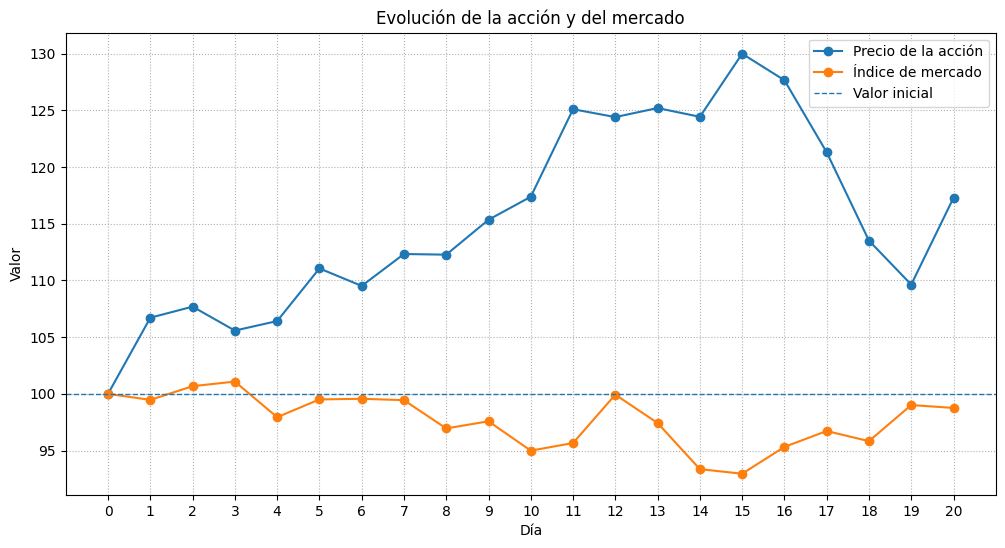

In [15]:

import numpy as np
import matplotlib.pyplot as plt
# ==========================================================
# DATOS DEL MODELO
# ==========================================================

# Estados:
# 0 = Alcista
# 1 = Constante
# 2 = Bajista

P = np.array([
    [0.80, 0.15, 0.05],
    [0.15, 0.70, 0.15],
    [0.05, 0.15, 0.80]
])

# ==========================================================
# MATRIZ DE EMISIÓN
# ==========================================================

# Observaciones:
# 0 = Subió
# 1 = Constante
# 2 = Bajó

B = np.array([
    [0.80, 0.15, 0.05],   # Alcista
    [0.10, 0.80, 0.10],   # Constante
    [0.05, 0.15, 0.80]    # Bajista
])

# ==========================================================
# PROBABILIDADES INICIALES
# ==========================================================
v0 = np.array([0.3, 0.4, 0.3])

# ==========================================================
# OBSERVACIONES DURANTE 20 DÍAS
# ==========================================================

# 0 = Subió
# 1 = Constante
# 2 = Bajó

observaciones = [
    0, 2, 0, 0, 2,
    1, 2, 0, 2, 0,
    0, 2, 1, 0, 2,
    0, 2, 0, 1, 0
]

T = len(observaciones)
n_estados = 3

# Nombres de los estados
nombres = [
    "Alcista",
    "Constante",
    "Bajista"
]

# ==========================================================
# 1. ALGORITMO DE VITERBI
# ==========================================================

# delta[t,j] = mayor probabilidad de una trayectoria
# que termina en el estado j en el día t.
delta = np.zeros((T, n_estados))

# psi[t,j] = estado anterior que produce la
# trayectoria más probable.
psi = np.zeros((T, n_estados), dtype=int)

# ----------------------------------------------------------
# Inicialización
# ----------------------------------------------------------
delta[0] = v0 * B[:, observaciones[0]]

# ----------------------------------------------------------
# Recursión
# ----------------------------------------------------------

for t in range(1, T):
    for j in range(n_estados):

        probabilidades = delta[t-1] * P[:, j]
        psi[t, j] = np.argmax(probabilidades)
        delta[t, j] = (
            np.max(probabilidades)
            * B[j, observaciones[t]]
        )

# ----------------------------------------------------------
# Estado final más probable
# ----------------------------------------------------------
estado_final = np.argmax(delta[T-1])

# ----------------------------------------------------------
# Reconstrucción de la trayectoria
# ----------------------------------------------------------

trayectoria_viterbi = [estado_final]

for t in range(T-1, 0, -1):
    estado_final = psi[t, estado_final]
    trayectoria_viterbi.append(estado_final)
trayectoria_viterbi.reverse()

# ==========================================================
# MOSTRAR LA TRAYECTORIA DE VITERBI
# ==========================================================

print("TRAYECTORIA MÁS PROBABLE")
print("------------------------")

for t in range(T):

    print(
        f"Día {t + 1:2d}: "
        f"{nombres[trayectoria_viterbi[t]]}"
    )

print("\nProbabilidad de la trayectoria:")
print(delta[T-1].max())

# ==========================================================
# 2. SIMULACIÓN DE LA ACCIÓN Y DEL MERCADO
# ==========================================================

# Semilla para que la simulación sea reproducible
np.random.seed(7)

# Valores iniciales
accion_inicial = 100
mercado_inicial = 100
accion = [accion_inicial]
mercado = [mercado_inicial]

# ==========================================================
# RENDIMIENTO PROMEDIO DE LA ACCIÓN
# ==========================================================

rendimiento_medio_accion = {
    0:  0.008,    # Alcista
    1:  0.000,    # Constante
    2: -0.008     # Bajista
}

# Volatilidad diaria de la acción
volatilidad_accion = 0.035

# ==========================================================
# RENDIMIENTO PROMEDIO DEL MERCADO
# ==========================================================

rendimiento_medio_mercado = {
    0:  0.004,    # Alcista
    1:  0.000,    # Constante
    2: -0.004     # Bajista
}

# Volatilidad diaria del mercado
volatilidad_mercado = 0.020

# ==========================================================
# EVOLUCIÓN DÍA POR DÍA
# ==========================================================

for estado in trayectoria_viterbi:
    # ------------------------------------------------------
    # Rendimiento de la acción
    # ------------------------------------------------------

    rendimiento_accion = np.random.normal(
        rendimiento_medio_accion[estado],
        volatilidad_accion
    )

    # Evitar variaciones extremas

    rendimiento_accion = np.clip(
        rendimiento_accion,
        -0.08,
        0.08
    )

    # ------------------------------------------------------
    # Rendimiento del mercado
    # ------------------------------------------------------

    rendimiento_mercado = np.random.normal(
        rendimiento_medio_mercado[estado],
        volatilidad_mercado
    )

    rendimiento_mercado = np.clip(
        rendimiento_mercado,
        -0.05,
        0.05
    )

    # ------------------------------------------------------
    # Actualizar precios
    # ------------------------------------------------------

    accion_nueva = (
        accion[-1]
        * (1 + rendimiento_accion)
    )

    mercado_nuevo = (
        mercado[-1]
        * (1 + rendimiento_mercado)
    )

    accion.append(accion_nueva)
    mercado.append(mercado_nuevo)

# ==========================================================
# 3. MOSTRAR EVOLUCIÓN DE LA ACCIÓN
# ==========================================================
print("\nEVOLUCIÓN DE LA ACCIÓN")
print("----------------------")

for t in range(T):
    rendimiento = (
        accion[t + 1] / accion[t] - 1
    ) * 100

    print(
        f"Día {t + 1:2d} | "
        f"{nombres[trayectoria_viterbi[t]]:10s} | "
        f"Precio = {accion[t + 1]:7.2f} | "
        f"Variación = {rendimiento:+6.2f}%"
    )
# ==========================================================
# 4. VALORES INICIALES Y FINALES
# ==========================================================

print("\nVALORES FINALES")
print("---------------")
print( f"Acción:  {accion[0]:.2f} -> {accion[-1]:.2f}")
print(f"Mercado: {mercado[0]:.2f} -> {mercado[-1]:.2f}")
variacion_accion  = ( accion[-1] / accion[0] - 1) * 100
variacion_mercado = ( mercado[-1] / mercado[0] - 1) * 100

print( f"Variación total de la acción: " f"{variacion_accion:+.2f}%")

print( f"Variación total del mercado: " f"{variacion_mercado:+.2f}%")

# ==========================================================
# 5. GRÁFICO
# ==========================================================

dias = np.arange(T + 1)
plt.figure(figsize=(12, 6))
plt.plot(
    dias,
    accion,
    marker="o",
    label="Precio de la acción"
)

plt.plot(
    dias,
    mercado,
    marker="o",
    label="Índice de mercado"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="Valor inicial"
)

plt.xlabel("Día")
plt.ylabel("Valor")
plt.title(
    "Evolución de la acción y del mercado"
)

plt.xticks(dias)
plt.legend()
plt.grid(linestyle=":")
plt.show()

## 8.  Ejercicios

### Ejercicio 1. Probabilidades de transición

Una cadena de Markov tiene tres estados $A$, $B$ y $C$, con matriz de transición

$$
P =
\begin{pmatrix}
0.6 & 0.3 & 0.1 \\
0.2 & 0.5 & 0.3 \\
0.1 & 0.2 & 0.7
\end{pmatrix}.
$$

Si inicialmente el sistema se encuentra en el estado $A$:

1. Calcule la probabilidad de encontrarse en $B$ después de dos pasos.
2. Calcule la probabilidad de la trayectoria $A\to B\to C$.
3. Calcule la probabilidad de encontrarse en $C$ después de tres pasos.

### Ejercicio 2. Trayectorias y verosimilitud

Considere una cadena de Markov con estados $S$ (soleado) y $L$ (lluvioso), cuya matriz de transición es

$$
P =
\begin{pmatrix}
0.8 & 0.2 \\
0.4 & 0.6
\end{pmatrix}.
$$

1. Calcule la probabilidad de la trayectoria

   $$
   S\to S\to L\to L\to S.
   $$

2. Calcule la probabilidad de la trayectoria

   $$
   S\to L\to S\to L\to S.
   $$

3. Compare las dos trayectorias e indique cuál tiene mayor probabilidad.

### Ejercicio 3. Estimación de una matriz de transición

Durante $20$ días se registra el estado de una máquina, que puede encontrarse en funcionamiento $F$ o en mantenimiento $M$:

```text
F, F, F, M, M, F, F, M, F, F, F, M, M, M, F, F, M, M, F, F
```

A partir de estos datos:

1. Construya la matriz de frecuencias de transición.
2. Estime la matriz de transición $P$ mediante frecuencias relativas.
3. Utilice la matriz estimada para calcular la probabilidad de que una máquina que actualmente está en funcionamiento se encuentre en mantenimiento después de dos días.

### Ejercicio 4. Evolución de una distribución

Una población se clasifica en tres grupos: jóvenes $J$, adultos $A$ y mayores $M$. La matriz de transición es

$$
P =
\begin{pmatrix}
0.5 & 0.4 & 0.1 \\
0.1 & 0.7 & 0.2 \\
0.0 & 0.3 & 0.7
\end{pmatrix}.
$$

Inicialmente, el $70\%$ de la población es joven, el $20\%$ adulta y el $10\%$ mayor.

1. Determine la distribución de la población después de un paso.
2. Determine la distribución después de tres pasos.
3. Implemente el cálculo en Python y represente gráficamente la evolución de las tres poblaciones durante $20$ pasos.
4. ¿Qué ocurre con la distribución cuando aumenta el número de pasos?

### Ejercicio 5. Simulación de una cadena de Markov

El comportamiento de un mercado puede clasificarse en tres estados:

```text
A = al alza
E = estable
B = a la baja
```

La matriz de transición es

$$
P =
\begin{pmatrix}
0.7 & 0.2 & 0.1 \\
0.2 & 0.6 & 0.2 \\
0.1 & 0.2 & 0.7
\end{pmatrix}.
$$

Suponga que el mercado comienza en el estado $A$.

1. Implemente en Python un algoritmo que simule una trayectoria del mercado durante $50$ días.
2. Represente gráficamente la trayectoria obtenida.
3. Repita la simulación varias veces. ¿Las trayectorias obtenidas son iguales?
4. Analice cómo la matriz de transición determina el comportamiento observado en las simulaciones.

### Ejercicio 6. Cadena de Markov oculta y algoritmo de Viterbi

El comportamiento de un mercado puede encontrarse en dos estados ocultos:

```text
A = alcista
B = bajista
```

La matriz de transición es

$$
P =
\begin{pmatrix}
0.8 & 0.2 \\
0.3 & 0.7
\end{pmatrix}.
$$

Cada día se observa si una acción sube $(+)$ o baja $(-)$. Las probabilidades de emisión son:

| Estado | $+$ | $-$ |
|:---:|---:|---:|
| $A$ | 0.8 | 0.2 |
| $B$ | 0.3 | 0.7 |

Para la secuencia de observaciones

$$
+,+,-,-,+,
$$

determine la trayectoria de estados ocultos más probable utilizando el **algoritmo de Viterbi**.

### Ejercicio 7. Comparación de modelos de Markov ocultos

Se desea modelar el comportamiento de un mercado mediante una cadena de Markov oculta con dos estados:

```text
A = mercado al alza
B = mercado a la baja
```

Cada día se observa si una acción sube $(+)$ o baja $(-)$.

Se consideran los siguientes dos modelos.

#### Modelo 1

$$
P_1 =
\begin{pmatrix}
0.8 & 0.2 \\
0.3 & 0.7
\end{pmatrix}.
$$

Las probabilidades de emisión son:

| Estado | $+$ | $-$ |
|:---:|---:|---:|
| $A$ | 0.8 | 0.2 |
| $B$ | 0.3 | 0.7 |

#### Modelo 2

$$
P_2 =
\begin{pmatrix}
0.6 & 0.4 \\
0.4 & 0.6
\end{pmatrix}.
$$

Las probabilidades de emisión son:

| Estado | $+$ | $-$ |
|:---:|---:|---:|
| $A$ | 0.7 | 0.3 |
| $B$ | 0.4 | 0.6 |

Considere la secuencia de observaciones

$$
+,-,+,+,-.
$$

Suponga que la probabilidad inicial de cada estado es $0.5$.

1. Calcule la verosimilitud de la secuencia de observaciones bajo cada modelo.
2. Utilice el algoritmo de Viterbi para encontrar la trayectoria de estados ocultos más probable bajo cada modelo.
3. Explique cómo las diferencias entre las matrices de transición y de emisión afectan los resultados.